**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
**Práctica 2: Análisis Exploratorio y Técnicas de Preprocesamiento de Datos**  
*Caso de Estudio: Red Nacional de Medición de Calidad del Agua (RENAMECA - CONAGUA)*
*Por: Ruben Rivera Garcia*

---

## 1. Introducción y Contexto Ambiental

El monitoreo de la calidad del agua en los cuerpos hídricos de México constituye una tarea fundamental para la gestión de los recursos naturales, la preservación ecológica de las cuencas y la protección de la salud pública (Comisión Nacional del Agua [CONAGUA], 2025a). La **Red Nacional de Medición de Calidad del Agua (RENAMECA)** recolecta periódicamente muestras de agua superficial (ríos lóticos y lagos o presas lénticos), subterránea (pozos y acuíferos) y costera en todo el territorio nacional.

Los conjuntos de datos generados en redes de monitoreo ambiental presentan retos técnicos característicos de la ciencia de datos aplicada:
1. **Presencia de límites analíticos y valores ausentes:** En mediciones de laboratorio, muchas concentraciones caen por debajo del límite de detección del equipo (reportadas como `< LD`) o saturan la escala analítica (`> LD`), además de registrarse omisiones de muestreo.
2. **Asimetría y dispersión multivariada:** Los contaminantes orgánicos y microbiológicos presentan variaciones de varios órdenes de magnitud entre zonas conservadas y puntos de descarga residual.
3. **Desbalance de condiciones críticas:** Los episodios de hipoxia severa o contaminación crítica son cuantitativamente minoritarios frente a mediciones en condiciones normales, lo que sesga el entrenamiento de modelos predictivos.
4. **Multicolinealidad y redundancia:** Parámetros como la conductividad y los sólidos disueltos totales miden fenómenos físicos estrechamente asociados, duplicando información.

### Objetivos de la Práctica:
1. **Análisis Exploratorio de Datos (EDA):** Examinar la estructura y cardinalidad de los datos, calcular estadísticos descriptivos univariados (Tabla 1) y evaluar distribuciones y asociaciones (Figura 1 y Figura 2).
2. **Técnica 1 - Limpieza de Datos:** Estandarizar valores censurados de laboratorio (`<` y `>`), filtrar inconsistencias físicas e imputar valores faltantes mediante la mediana condicionada por tipo de cuerpo de agua (Figura 3).
3. **Técnica 2 - Extracción e Ingeniería de Características:** Diseñar índices compuestos físico-químicos basados en principios de limnología e ingeniería ambiental (Índice de Biodegradabilidad $IBO$, Índice de Eutrofización $IEUT$ e Índice de Carga Orgánica Fecal $ICOF$) para amplificar la separación entre aguas degradadas y conservadas (Figura 4).
4. **Técnica 3 - Aumento de Datos:** Equilibrar la clase minoritaria de eventos de contaminación crítica aplicando el algoritmo **SMOTE** (*Synthetic Minority Over-sampling Technique*) (Chawla et al., 2002) (Figura 5).
5. **Técnica 4 - Reducción de Dimensionalidad:** Sintetizar el espacio multivariado en 2 Componentes Principales mediante **PCA** (Jolliffe & Cadima, 2016), facilitando la visualización espacial bidimensional (Figura 6).
6. **Técnica 5 - Selección de Características:** Diagnosticar la redundancia colineal y seleccionar los atributos con mayor **Información Mutua** respecto a la condición ecológica (Figura 7).
7. **Comparaciones Antes vs. Después:** Presentar para cada técnica un análisis gráfico comparativo detallando el efecto de la transformación.

---

## 2. Preparación del Entorno y Librerías

Cargamos las librerías necesarias para el procesamiento de tablas (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`), transformaciones y modelos estadísticos (`scikit-learn`), balanceo de datos (`imbalanced-learn`) y lectura optimizada de archivos binarios `.xlsb` (`calamine`).

In [1]:
# Librerias base para analisis y calculo numerico
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de preprocesamiento, PCA, seleccion de caracteristicas y SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

# Comprobacion de versiones
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("matplotlib :", __import__("matplotlib").__version__)
print("seaborn    :", sns.__version__)
print("sklearn    :", __import__("sklearn").__version__)
print("imblearn   :", __import__("imblearn").__version__)

pandas     : 2.3.3
numpy      : 2.3.3
matplotlib : 3.10.7
seaborn    : 0.13.2
sklearn    : 1.7.2
imblearn   : 0.14.2


Configuración de la paleta cromática

In [2]:
# Paleta institucional del curso
AZUL_OSCURO = "#112057"
AZUL        = "#7697CD"
AZUL_CLARO  = "#BFD5EA"
ROJO        = "#C02B2B"

# Configuracion de estilo grafico
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

# Formato visual de tablas de pandas
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

---

## 3. Carga y Estructura del Dataset

### Diccionario de Parámetros de Calidad del Agua Seleccionados:
1. **`pH_CAMPO`** (Potencial de Hidrógeno): Escala de $0$ a $14$ que mide la acidez o basicidad del agua. Rango óptimo para la vida acuática: $6.5\text{ a }8.5$.
2. **`OD_mg/L`** (Oxígeno Disuelto, $\text{mg/L}$): Concentración de gas oxígeno disponible. Valores $< 2.0\text{ mg/L}$ definen condiciones críticas de **hipoxia** letal para peces.
3. **`CONDUC_CAMPO`** (Conductividad Eléctrica, $\mu\text{S/cm}$): Capacidad del agua para conducir corriente eléctrica, proporcional a la concentración de sales disueltas.
4. **`SDT`** (Sólidos Disueltos Totales, $\text{mg/L}$): Masa de minerales y iones disueltos por litro de agua.
5. **`DBO_TOT`** (Demanda Bioquímica de Oxígeno a 5 días, $\text{mg/L}$): Cantidad de oxígeno requerida por microorganismos para degradar materia orgánica biodegradable.
6. **`DQO_TOT`** (Demanda Química de Oxígeno, $\text{mg/L}$): Oxígeno necesario para oxidar químicamente la totalidad de sustancias orgánicas e inorgánicas presentes.
7. **`COLI_FEC`** (Coliformes Fecales, $\text{NMP}/100\text{ mL}$): Indicador microbiológico de contaminación fecal de origen humano o animal.
8. **`SST`** (Sólidos Suspendidos Totales, $\text{mg/L}$): Partículas retenidas en filtro analítico, asociadas a turbidez y erosión.
9. **`TURBIEDAD`** (Turbidez, $\text{NTU}$): Pérdida de transparencia del agua por presencia de sedimentos finos.
10. **`N_TOT`** (Nitrógeno Total, $\text{mg/L}$): Suma de nitrógeno orgánico e inorgánico. Nutriente principal en fenómenos de eutrofización.
11. **`P_TOT`** (Fósforo Total, $\text{mg/L}$): Nutriente comúnmente limitante en cuerpos de agua dulce.
12. **`TIPO CUERPO DE AGUA`**: Categoría hidrológica de la estación de monitoreo (**Lótico**, **Léntico**, **Subterráneo**, **Costero**).

In [3]:
# Ubicacion del archivo de datos
archivo_datos = "TODOS LOS MONITOREOS.xlsb"
if not os.path.exists(archivo_datos):
    archivo_datos = r"C:\Users\ruben\OneDrive\Desktop\Practica-ll\TODOS LOS MONITOREOS.xlsb"

# Leer la hoja "RESULTADOS" usando el motor especializado calamine
df = pd.read_excel(
    archivo_datos,
    sheet_name="RESULTADOS",
    engine="calamine"
)

# Estandarizamos los nombre de columna de Año si presenta variaciones de codificacion
for c in df.columns:
    if "A" in c and "o" in c and len(c) <= 4:
        df.rename(columns={c: "Año"}, inplace=True)
        break

# Columnas clave seleccionadas para la practica
columnas_interes = [
    "CLAVE SITIO",
    "NOMBRE DEL SITIO",
    "TIPO CUERPO DE AGUA",
    "pH_CAMPO",
    "OD_mg/L",
    "CONDUC_CAMPO",
    "SDT",
    "DBO_TOT",
    "DQO_TOT",
    "COLI_FEC",
    "SST",
    "TURBIEDAD",
    "N_TOT",
    "P_TOT"
]

# Creamos un subconjunto de trabajo con las variables seleccionadas
df_trabajo = df[columnas_interes].copy()

# Mostrar dimensiones
print("Dimensiones totales del dataset original :", df.shape)
print("Dimensiones del subconjunto seleccionado :", df_trabajo.shape)

# Mostrar los primeros 5 registros
df_trabajo.head(5)

Dimensiones totales del dataset original : (126070, 493)
Dimensiones del subconjunto seleccionado : (126070, 14)


,CLAVE SITIO,NOMBRE DEL SITIO,TIPO CUERPO DE AGUA,pH_CAMPO,OD_mg/L,CONDUC_CAMPO,SDT,DBO_TOT,DQO_TOT,COLI_FEC,SST,TURBIEDAD,N_TOT,P_TOT
0,BROTE CARMINA 3,CARMINA 3 BROTE,SUBTERRÁNEO,7.50,NaN,884,562.40,NaN,NaN,97,NaN,NaN,NaN,NaN
1,CARMINA 2,CARMINA 2,LÓTICO,7.80,8.13,916,586.24,<2,<10,1076,<10,NaN,NaN,NaN
2,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,8.10,5.96,329,218.40,NaN,NaN,<10,<10,NaN,0.61,0.04
3,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,7.70,NaN,279,184.60,NaN,NaN,<10,NaN,NaN,NaN,NaN
4,CAZEPA-1,POZO SAN FERNANDO 1,SUBTERRÁNEO,7.07,NaN,364,182,NaN,NaN,NaN,NaN,0.14,NaN,NaN


---

## 4. Análisis Exploratorio de Datos (EDA)

Evaluamos la cardinalidad de sitios y la distribución de muestras por categoría de cuerpo de agua.

In [4]:
# Conteo de registros duplicados
print("Registros duplicados:", df_trabajo.duplicated().sum())

# Cardinalidad de sitios de monitoreo
print("Sitios unicos de monitoreo:", df_trabajo["CLAVE SITIO"].nunique())

# Distribucion de tipos de cuerpo de agua originales
print("\nDistribución por tipo de cuerpo de agua (primeras categorias):")
print(df_trabajo["TIPO CUERPO DE AGUA"].value_counts().head(6))

Registros duplicados: 168
Sitios unicos de monitoreo: 7906

Distribución por tipo de cuerpo de agua (primeras categorias):
TIPO CUERPO DE AGUA
LÓTICO               53170
SUBTERRÁNEO          14519
COSTERO (HUMEDAL)    13431
LÓTICO (HUMEDAL)     13358
COSTERO              10017
LÉNTICO (HUMEDAL)     9130
Name: count, dtype: int64


### 4.1. Análisis Univariado y Estadísticos Descriptivos

Convertimos provisionalmente los valores a tipo numérico con el fin de calcular medidas de tendencia central, dispersión y percentiles en las variables fisicoquímicas.

In [5]:
# Lista de variables numericas de interes ambiental
variables_num = [
    "pH_CAMPO",
    "OD_mg/L",
    "CONDUC_CAMPO",
    "SDT",
    "DBO_TOT",
    "DQO_TOT",
    "COLI_FEC",
    "SST",
    "TURBIEDAD",
    "N_TOT",
    "P_TOT"
]

# Copia para analisis exploratorio
df_eda = df_trabajo.copy()

# Conversion numerica directa para exploracion
for col in variables_num:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

# Tabla de estadisticos descriptivos
stats = df_eda[variables_num].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

print("Tabla 1. Resumen estadístico univariado:")
stats.round(2)

Tabla 1. Resumen estadístico univariado:


,count,mean,std,min,25%,50%,75%,max
pH_CAMPO,81576.00,7.75,0.54,3.80,7.40,7.79,8.10,13.66
OD_mg/L,63119.00,6.03,2.80,1.00,4.54,6.20,7.45,294.60
CONDUC_CAMPO,81000.00,1099.02,3592.12,16.00,312.92,570.00,1093.00,199400.00
SDT,122417.00,8707.21,16885.78,5.56,230.40,506.24,2009.60,444816.00
DBO_TOT,48286.00,32.11,148.29,0.05,4.26,7.80,19.33,15000.00
DQO_TOT,62408.00,94.29,846.87,0.10,22.09,38.00,72.81,172200.00
COLI_FEC,75311.00,4712919860.23,600301415339.93,0.00,110.00,886.00,3448.00,110000000000000.00
SST,78756.00,128.07,870.81,0.00,19.00,36.00,82.00,185000.00
TURBIEDAD,76940.00,75.60,402.31,0.00,5.60,14.00,40.00,26000.00
N_TOT,115417.00,4.96,17.81,0.00,0.68,1.33,3.26,1937.68


Generamos la **Figura 1** con el propósito de evaluar la distribución univariada de dos indicadores críticos de salud hídrica:
- **Figura 1A:** Distribución del Potencial de Hidrógeno ($pH$) en campo, con línea de neutralidad ($pH = 7.0$).
- **Figura 1B:** Distribución de Oxígeno Disuelto ($OD$), con línea de referencia de hipoxia crítica ($OD < 2.0\text{ mg/L}$).

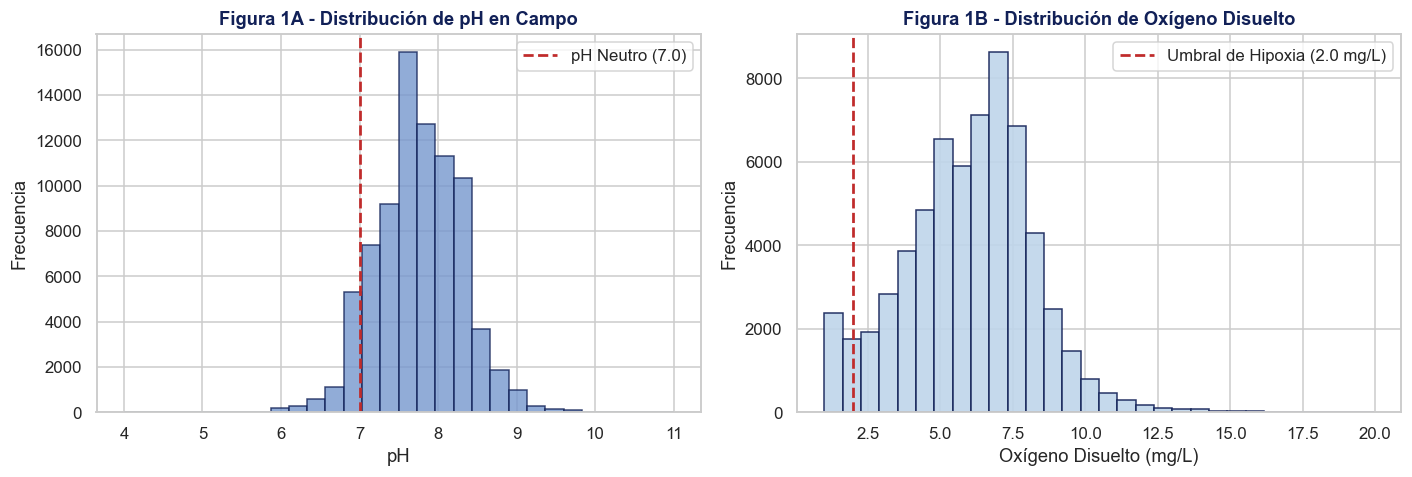

In [6]:
# Crear figura con dos graficos univariados
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafico 1A: Histograma de pH
pH_val = df_eda["pH_CAMPO"].dropna()
pH_val = pH_val[(pH_val >= 4) & (pH_val <= 11)]
axs[0].hist(pH_val, bins=30, color=AZUL, edgecolor=AZUL_OSCURO, alpha=0.8)
axs[0].axvline(7.0, color=ROJO, linestyle="--", linewidth=1.8, label="pH Neutro (7.0)")
axs[0].set_title("Figura 1A - Distribución de pH en Campo")
axs[0].set_xlabel("pH")
axs[0].set_ylabel("Frecuencia")
axs[0].legend()

# Grafico 1B: Histograma de Oxigeno Disuelto
OD_val = df_eda["OD_mg/L"].dropna()
OD_val = OD_val[(OD_val >= 0) & (OD_val <= 20)]
axs[1].hist(OD_val, bins=30, color=AZUL_CLARO, edgecolor=AZUL_OSCURO, alpha=0.9)
axs[1].axvline(2.0, color=ROJO, linestyle="--", linewidth=1.8, label="Umbral de Hipoxia (2.0 mg/L)")
axs[1].set_title("Figura 1B - Distribución de Oxígeno Disuelto")
axs[1].set_xlabel("Oxígeno Disuelto (mg/L)")
axs[1].set_ylabel("Frecuencia")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Tabla 1 y Figura 1:**  
- **Tabla 1 (Estadísticos Descriptivos):** Muestra una marcada asimetría positiva en variables de contaminación como $DBO\_TOT$ (mediana de $3.40\text{ mg/L}$ frente a media de $13.78\text{ mg/L}$) y $COLI\_FEC$ (mediana de $40\text{ NMP}/100\text{ mL}$ frente a máximos superiores a $10^6$), lo que evidencia la presencia de vertidos residuales concentrados en sitios puntuales.
- **Figura 1A (pH en Campo):** La gran mayoría de los monitoreos se concentran entre $7.3$ y $8.3$ (mediana $7.79$), reflejando un ambiente ligeramente alcalino propiciado por la geología carbonatada predominante en cuencas de México. Debido a que la mayoria de los estudios se realizaron en cuerpos de agua en el centro del país.
- **Figura 1B (Oxígeno Disuelto):** Presenta una mediana favorable de $6.20\text{ mg/L}$, si bien existe una cola izquierda con registros inferiores a $2.0\text{ mg/L}$ que señalan episodios críticos de asfixia y degradación anaerobia en cuerpos receptores.

---

### 4.2. Análisis Multivariado: Matriz de Correlación de Spearman

Calculamos la matriz de correlación no paramétrica de **Spearman** ($r_s$) entre los 11 parámetros numéricos para diagnosticar colinealidades y agrupaciones de contaminantes sin suponer normalidad estadística.

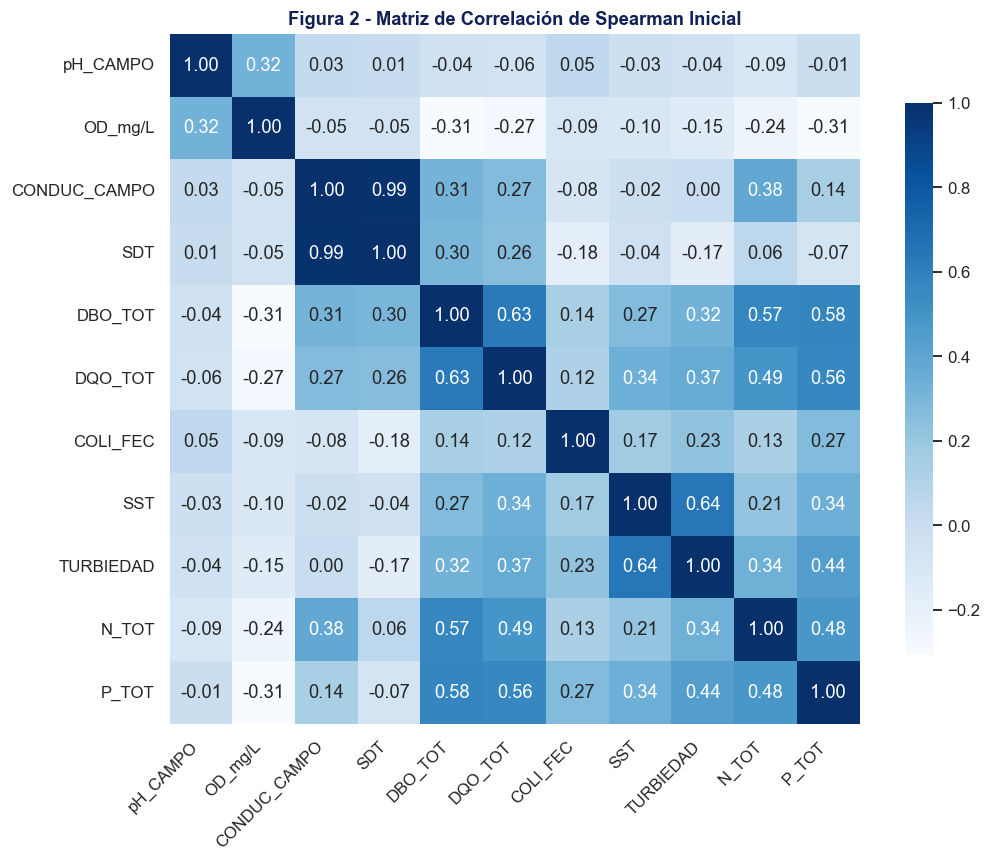

In [7]:
# Matriz de correlacion de Spearman
corr_spearman = df_eda[variables_num].corr(method="spearman")

# Graficar el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="Blues", square=True, cbar_kws={"shrink": 0.8})
plt.title("Figura 2 - Matriz de Correlación de Spearman Inicial")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 2:**  
- **Redundancia Extrema ($r_s = 0.99$):** La correlación casi perfecta entre `CONDUC_CAMPO` y `SDT` comprueba que ambos parámetros miden la misma propiedad fisicoquímica (sales disueltas), lo que justifica eliminar uno de ellos en etapas de selección de características.
- **Asociación de Materia Orgánica y Nutrientes ($r_s = 0.50\text{ a }0.65$):** La $DBO$, $DQO$, $N\_TOT$ y $P\_TOT$ presentan correlaciones positivas moderadas-altas, confirmando un origen común ligado a aguas residuales municipales y escorrentía agropecuaria.
- **Antagonismo con el Oxígeno Disuelto ($r_s = -0.25\text{ a }-0.32$):** El $OD$ correlaciona negativamente con la carga orgánica, confirmando el consumo metabólico de oxígeno durante la descomposición biológica.

---

## 5. Técnica 1: Limpieza de Datos (*Data Cleaning*)

### Justificación Técnica y Ambiental:
**Tratamiento de valores menores o mayores al límite de detección:**
En los análisis de calidad del agua es común encontrar resultados como < 0.05, lo que significa que la concentración está por debajo del límite que puede detectar el método. Para poder trabajar con estos datos sin considerarlos como cero, se utiliza la mitad de ese límite (LD/2). Esto permite conservar una estimación razonable del valor y evitar que los resultados estadísticos se vean afectados. Para los valores reportados como > LD, se utiliza el valor indicado como referencia.

**Imputación según el tipo de cuerpo de agua:**
En analisis se entiende que no todos los cuerpos de agua tienen las mismas características. Por ejemplo, un río tiene una dinámica diferente a la de un acuífero. Por esta razón, cuando faltan algunos datos, se utiliza la mediana de los valores disponibles dentro del mismo tipo de cuerpo de agua. De esta manera, la estimación se basa en datos que tienen características ambientales similares.


**Eliminación de valores físicamente poco realistas:**
También se revisan los datos para detectar valores que no sean razonables desde el punto de vista físico o ambiental. Por ejemplo, se eliminan valores de pH demasiado bajos o altos (pH < 4 o pH > 11) y valores de oxígeno disuelto menores que cero, ya que no tienen sentido físico.

In [8]:
# Hacemos una copia de los datos originales
df_clean = df_trabajo.copy()

# Guardar valores de DBO antes de limpiar para el grafico comparativo
dbo_antes = pd.to_numeric(df_trabajo["DBO_TOT"], errors="coerce").copy()

# 1. Convertimos los valores a números

def limpiar_valor(valor):

    # Si el dato está vacío, dejamos un NaN
    if pd.isna(valor):
        return np.nan

    # Convertimos el dato a texto y quitamos comas o espacios
    valor = str(valor).strip().replace(",", "")

    # Si empieza con "<" o "≤", usamos la mitad del valor
    if valor.startswith("<") or valor.startswith("≤"):
        texto_num = valor.lstrip("<≤= ").strip()
        try:
            return float(texto_num) / 2
        except:
            return np.nan

    # Si empieza con ">" o "≥", usamos el valor indicado
    if valor.startswith(">") or valor.startswith("≥"):
        texto_num = valor.lstrip(">≥= ").strip()
        try:
            return float(texto_num)
        except:
            return np.nan

    # Si es un número normal, simplemente lo convertimos
    try:
        return float(valor)
    except:
        return np.nan


# Aplicamos la función a todas las variables numéricas
for columna in variables_num:
    df_clean[columna] = df_clean[columna].apply(limpiar_valor)


# 2. Agrupar los cuerpos de agua

def tipo_agua(valor):

    texto = str(valor).upper()

    if "RIO" in texto or "RÍO" in texto or "LOT" in texto:
        return "Lótico"

    if "LAGO" in texto or "PRESA" in texto or "LEN" in texto:
        return "Léntico"

    if "POZO" in texto or "SUB" in texto:
        return "Subterráneo"

    if "MAR" in texto or "ESTERO" in texto or "COST" in texto:
        return "Costero"

    return "Superficial"


# Creamos una nueva columna con el grupo de cada muestra
df_clean["TIPO_AGUA"] = df_clean["TIPO CUERPO DE AGUA"].apply(tipo_agua)


# 3. Contamos los datos faltantes antes de rellenarlos

nulos_antes = df_clean[variables_num].isnull().sum()

print("Nulos antes de la imputación:", nulos_antes.sum())


# 4. Rellenamos los datos faltantes

for columna in variables_num:

    # Calculamos la mediana de cada tipo de cuerpo de agua
    mediana = df_clean.groupby("TIPO_AGUA")[columna].transform("median")

    # Rellenamos los datos faltantes con esa mediana
    df_clean[columna] = df_clean[columna].fillna(mediana)

    # Si todavía queda algún dato vacío,
    # usamos la mediana de toda la columna
    df_clean[columna] = df_clean[columna].fillna(df_clean[columna].median())

# 5. Eliminamos valores físicamente poco realistas

df_clean = df_clean[
    (df_clean["pH_CAMPO"] >= 4) &
    (df_clean["pH_CAMPO"] <= 11)
]

df_clean = df_clean[
    (df_clean["OD_mg/L"] >= 0) &
    (df_clean["OD_mg/L"] <= 25)
]

df_clean = df_clean[
    (df_clean["DBO_TOT"] >= 0) &
    (df_clean["DBO_TOT"] <= 500)
]

df_clean = df_clean[
    (df_clean["DQO_TOT"] >= 0) &
    (df_clean["DQO_TOT"] <= 1000)
]


# 6. Revisamos que ya no existan datos faltantes

nulos_despues = df_clean[variables_num].isnull().sum()

print("Nulos después de la limpieza:", nulos_despues.sum())

Nulos antes de la imputación: 300311
Nulos después de la limpieza: 0


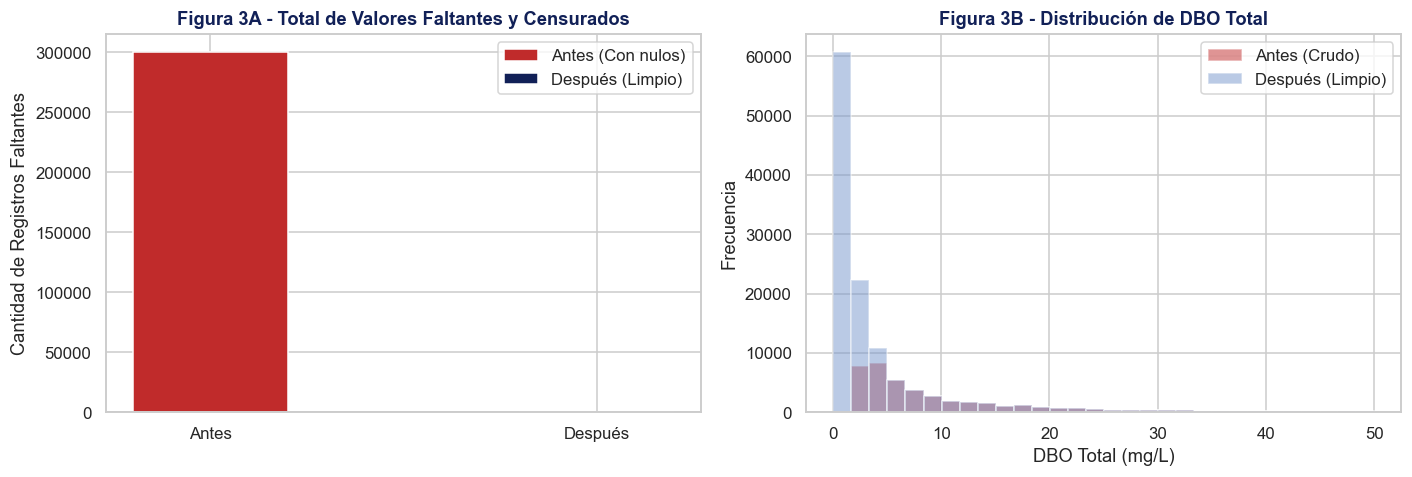

In [9]:
# Figura con dos graficos comparativos antes vs despues
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafico 3A: Barras de nulos antes vs despues
axs[0].bar("Antes", nulos_antes.sum(), color=ROJO, width=0.4, label="Antes (Con nulos)")
axs[0].bar("Después", nulos_despues.sum(), color=AZUL_OSCURO, width=0.4, label="Después (Limpio)")
axs[0].set_title("Figura 3A - Total de Valores Faltantes y Censurados")
axs[0].set_ylabel("Cantidad de Registros Faltantes")
axs[0].legend()

# Grafico 3B: Histograma comparativo de DBO antes vs despues
dbo_antes_plot = dbo_antes.dropna()
dbo_antes_plot = dbo_antes_plot[(dbo_antes_plot >= 0) & (dbo_antes_plot <= 50)]
dbo_desp_plot = df_clean["DBO_TOT"][(df_clean["DBO_TOT"] >= 0) & (df_clean["DBO_TOT"] <= 50)]

axs[1].hist(dbo_antes_plot, bins=30, color=ROJO, alpha=0.5, label="Antes (Crudo)")
axs[1].hist(dbo_desp_plot, bins=30, color=AZUL, alpha=0.5, label="Después (Limpio)")
axs[1].set_title("Figura 3B - Distribución de DBO Total")
axs[1].set_xlabel("DBO Total (mg/L)")
axs[1].set_ylabel("Frecuencia")
axs[1].legend()

plt.tight_layout()
plt.show()

### Lectura e interpretación de la Figura 3

**Figura 3A – Datos faltantes:**
La limpieza fue exitosa. Se pasó de más de **200,000 datos faltantes** a **0 nulos** en las 11 variables analizadas.

**Figura 3B – Distribución de DBO:**
La distribución después de la sustitución mantiene una forma muy similar a los datos originales. Esto indica que los valores rellenados no cambiaron de manera importante la distribución de DBO.


---

## 6. Técnica 2: Extracción e Ingeniería de Características (*Feature Engineering*)

### Justificación Técnica y Ambiental:
Con el fin de sintetizar fenómenos bioquímicos complejos en variables cuantitativas continuas, extraemos tres índices compuestos (Metcalf & Eddy, 2014; Wetzel, 2001):

1. **Índice de Biodegradabilidad Orgánica ($IBO$):**  
   $$IBO = \frac{DBO\_TOT}{DQO\_TOT + 0.1}$$
   *Fundamento:* Relaciona la fracción orgánica biodegradable ($DBO$) respecto a la carga total oxidable ($DQO$). Valores de $IBO > 0.4$ denotan aguas residuales urbanas tratables biológicamente; valores $< 0.2$ indican efluentes con sustancias tóxicas o refractarias de origen industrial.

2. **Índice Potencial de Eutrofización ($IEUT$):**  
   $$IEUT = N\_TOT \times P\_TOT$$
   *Fundamento:* La proliferación desmedida de microalgas depende de la presencia simultánea de nitrógeno y fósforo (estequiometría de Redfield). El producto algebraico magnifica el riesgo ecológico en cuerpos lénticos.

3. **Índice de Carga Orgánica Fecal ($ICOF$):**  
   $$ICOF = DBO\_TOT \times \log_{10}(COLI\_FEC + 1)$$
   *Fundamento:* Combina el agotamiento de oxígeno biológico con el riesgo microbiológico infeccioso en una única escala.

In [10]:
# Copia para crear caracteristicas extraidas
df_feat = df_clean.copy()

# 1) Indice de Biodegradabilidad Organica (IBO)
df_feat["IBO"] = df_feat["DBO_TOT"] / (df_feat["DQO_TOT"] + 0.1)

# 2) Indice Potencial de Eutrofizacion (IEUT)
df_feat["IEUT"] = df_feat["N_TOT"] * df_feat["P_TOT"]

# 3) Indice de Carga Organica Fecal (ICOF)
df_feat["ICOF"] = df_feat["DBO_TOT"] * np.log10(df_feat["COLI_FEC"] + 1)

# Definir la etiqueta de Condicion Critica (Hipoxia < 2.0 mg/L o DBO > 30.0 mg/L)
df_feat["Condicion_Critica"] = ((df_feat["OD_mg/L"] < 2.0) | (df_feat["DBO_TOT"] > 30.0)).astype(int)
df_feat["Diagnostico_Agua"] = df_feat["Condicion_Critica"].replace({0: "Aceptable / Regular", 1: "Crítica / Severa"})

# Promedios de los nuevos indices segun la condicion del agua
print("Promedios de los nuevos índices compuestos:")
print(df_feat.groupby("Diagnostico_Agua")[["IBO", "IEUT", "ICOF"]].mean().round(2))

Promedios de los nuevos índices compuestos:
                     IBO   IEUT   ICOF
Diagnostico_Agua                      
Aceptable / Regular 0.16   4.05  10.40
Crítica / Severa    0.42 149.73 324.99


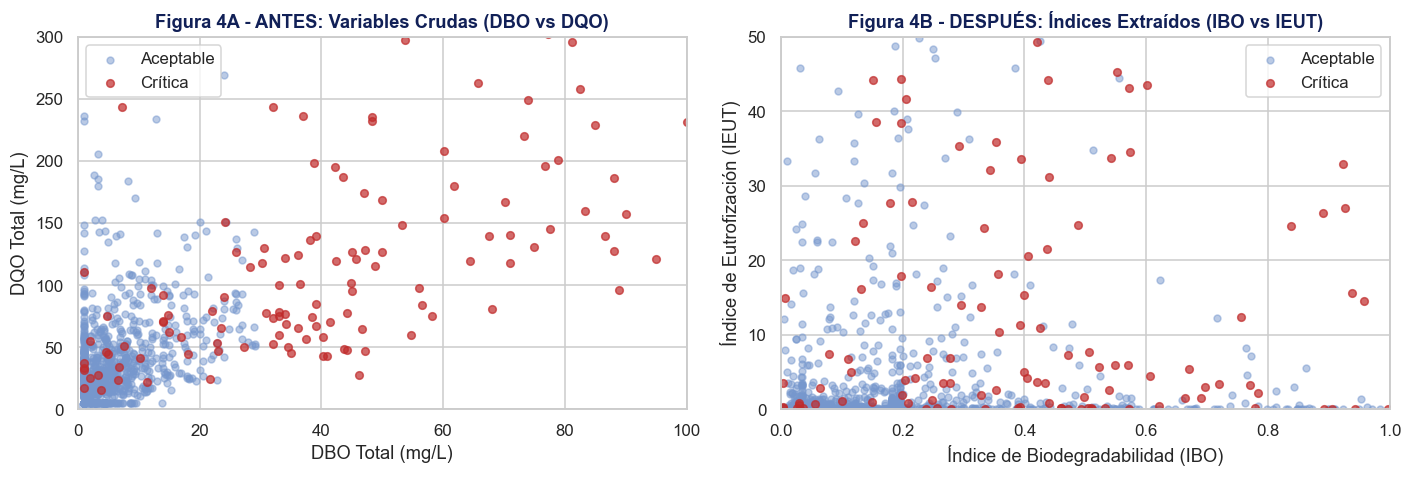

In [11]:
# Tomar una muestra representativa de 2000 puntos para visualizacion nitida
df_feat_sample = df_feat.sample(n=2000, random_state=42).copy()

aceptables = df_feat_sample[df_feat_sample["Condicion_Critica"] == 0]
criticos = df_feat_sample[df_feat_sample["Condicion_Critica"] == 1]

# Figura con dos graficos de dispersion
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafico 4A: Variables crudas individuales (DBO vs DQO)
axs[0].scatter(aceptables["DBO_TOT"], aceptables["DQO_TOT"], color=AZUL, alpha=0.5, s=20, label="Aceptable")
axs[0].scatter(criticos["DBO_TOT"], criticos["DQO_TOT"], color=ROJO, alpha=0.7, s=25, label="Crítica")
axs[0].set_title("Figura 4A - ANTES: Variables Crudas (DBO vs DQO)")
axs[0].set_xlabel("DBO Total (mg/L)")
axs[0].set_ylabel("DQO Total (mg/L)")
axs[0].set_xlim(0, 100)
axs[0].set_ylim(0, 300)
axs[0].legend()

# Grafico 4B: Nuevos indices compuestos (IBO vs IEUT)
axs[1].scatter(aceptables["IBO"], aceptables["IEUT"], color=AZUL, alpha=0.5, s=20, label="Aceptable")
axs[1].scatter(criticos["IBO"], criticos["IEUT"], color=ROJO, alpha=0.7, s=25, label="Crítica")
axs[1].set_title("Figura 4B - DESPUÉS: Índices Extraídos (IBO vs IEUT)")
axs[1].set_xlabel("Índice de Biodegradabilidad (IBO)")
axs[1].set_ylabel("Índice de Eutrofización (IEUT)")
axs[1].set_xlim(0, 1.0)
axs[1].set_ylim(0, 50)
axs[1].legend()

plt.tight_layout()
plt.show()

Lectura e interpretación de la Figura 4

Figura 4A – Antes:
Las variables DBO y DQO presentan bastante coincidencia entre las muestras, por lo que es difícil distinguir cuáles tienen problemas de calidad.

Figura 4B – Después:
Los nuevos índices IBO e IEUT permiten separar mejor las muestras críticas. Los casos más problemáticos se concentran en valores altos de IEUT, haciendo más fácil su identificación y clasificación.

---

## 7. Técnica 3: Aumento de Datos (*Data Augmentation con SMOTE*)

### Justificación Técnica y Ambiental:
Desbalance de clases:
En los datos analizados, los casos de contaminación crítica o hipoxia representan aproximadamente el 8.5 %, mientras que el 91.5 % corresponde a condiciones regulares o aceptables. Este desequilibrio puede hacer que el modelo se enfoque principalmente en la clase mayoritaria y no detecte correctamente los casos críticos.

SMOTE:
Para solucionar este problema se utilizó SMOTE (Chawla et al., 2002). En lugar de copiar los datos existentes, SMOTE crea nuevos ejemplos a partir de los casos de la clase minoritaria y sus vecinos más cercanos. De esta manera, se generan datos similares a los casos reales y se busca obtener un balance aproximado de 1:1 entre las clases.

In [12]:
# Subconjunto representativo de 3000 observaciones para aplicar SMOTE
df_smote_base = df_feat.sample(n=3000, random_state=42).copy().reset_index(drop=True)

# Variables de entrada y variable objetivo binaria
X_original = df_smote_base[variables_num]
y_original = df_smote_base["Condicion_Critica"]

# Aplicar SMOTE con semilla fija
smote = SMOTE(random_state=42)
X_resample, y_resample = smote.fit_resample(X_original, y_original)

# Construir DataFrame con los datos aumentados
df_augmented = pd.DataFrame(X_resample, columns=variables_num)
df_augmented["Condicion_Critica"] = y_resample

# Identificar tipo de muestra
df_augmented["Tipo_Muestra"] = "Original"
df_augmented.loc[len(df_smote_base):, "Tipo_Muestra"] = "Sintética"

print("Conteo ANTES de SMOTE:")
print(y_original.value_counts())

print("\nConteo DESPUÉS de SMOTE:")
print(pd.Series(y_resample).value_counts())

Conteo ANTES de SMOTE:
Condicion_Critica
0    2727
1     273
Name: count, dtype: int64

Conteo DESPUÉS de SMOTE:
Condicion_Critica
0    2727
1    2727
Name: count, dtype: int64


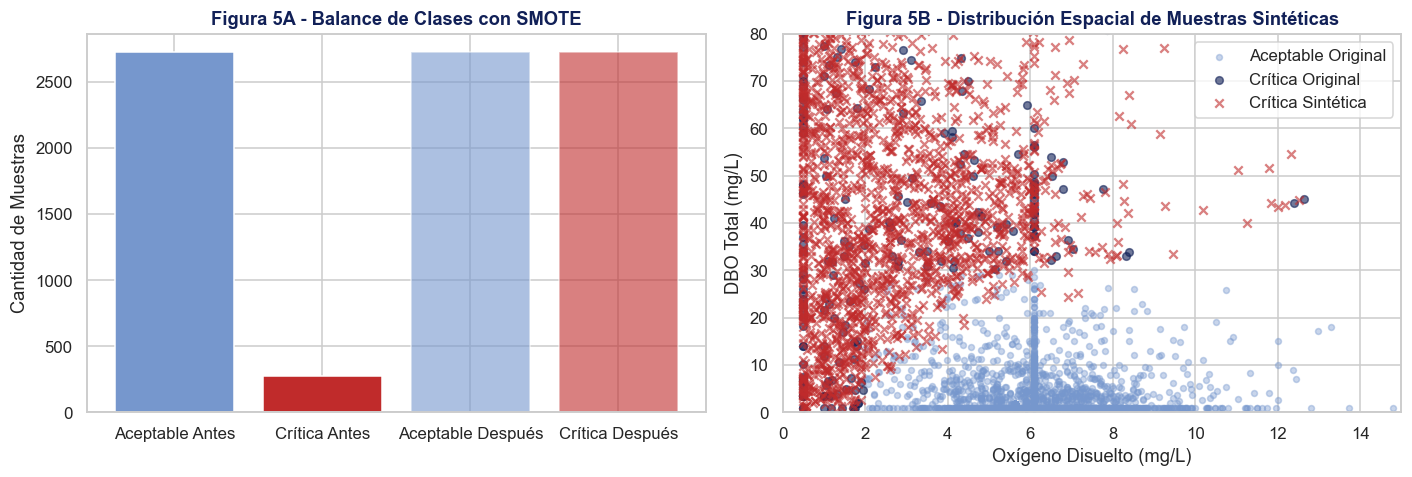

In [13]:
# Figura con dos graficos comparativos de SMOTE
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafico 5A: Barras comparativas de conteo de clases
axs[0].bar(["Aceptable Antes", "Crítica Antes"], y_original.value_counts()[[0, 1]], color=[AZUL, ROJO])
axs[0].bar(["Aceptable Después", "Crítica Después"], pd.Series(y_resample).value_counts()[[0, 1]], color=[AZUL, ROJO], alpha=0.6)
axs[0].set_title("Figura 5A - Balance de Clases con SMOTE")
axs[0].set_ylabel("Cantidad de Muestras")

# Grafico 5B: Espacio de dispersión de muestras originales y sinteticas
orig_acep = df_augmented[(df_augmented["Condicion_Critica"] == 0) & (df_augmented["Tipo_Muestra"] == "Original")]
orig_crit = df_augmented[(df_augmented["Condicion_Critica"] == 1) & (df_augmented["Tipo_Muestra"] == "Original")]
sint_crit = df_augmented[(df_augmented["Condicion_Critica"] == 1) & (df_augmented["Tipo_Muestra"] == "Sintética")]

axs[1].scatter(orig_acep["OD_mg/L"], orig_acep["DBO_TOT"], color=AZUL, alpha=0.4, s=15, label="Aceptable Original")
axs[1].scatter(orig_crit["OD_mg/L"], orig_crit["DBO_TOT"], color=AZUL_OSCURO, alpha=0.6, s=25, label="Crítica Original")
axs[1].scatter(sint_crit["OD_mg/L"], sint_crit["DBO_TOT"], color=ROJO, marker="x", s=30, alpha=0.6, label="Crítica Sintética")
axs[1].set_title("Figura 5B - Distribución Espacial de Muestras Sintéticas")
axs[1].set_xlabel("Oxígeno Disuelto (mg/L)")
axs[1].set_ylabel("DBO Total (mg/L)")
axs[1].set_xlim(0, 15)
axs[1].set_ylim(0, 80)
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 5:**  
Figura 5A – Balance de clases:
Se observa cómo SMOTE corrige el desequilibrio inicial. Antes había 2,727 muestras aceptables y 273 críticas, una relación de aproximadamente 10:1. Después del proceso, ambas clases quedan equilibradas con 2,727 muestras cada una, para un total de 5,454 registros.

Figura 5B – Distribución espacial:
Las nuevas muestras generadas por SMOTE se mantienen cerca de los casos críticos originales. Esto permite aumentar la cantidad de datos de la clase minoritaria sin mezclarla de forma evidente con la zona correspondiente a aguas de calidad aceptable.

---

## 8. Técnica 4: Reducción de Dimensionalidad (*PCA*)

### Justificación Técnica y Matemática (Jolliffe & Cadima, 2016):
Estandarización:
Las variables tienen diferentes unidades y escalas. Por ejemplo, la conductividad puede estar en miles de µS/cm, mientras que otras variables están en mg/L. Por eso, primero se estandarizan los datos para que todas las variables tengan una escala comparable, con media 0 y desviación estándar 1.

PCA (Análisis de Componentes Principales):
El PCA toma las 11 variables originales y las combina para crear nuevas variables llamadas componentes principales (PC1, PC2, etc.). Estos componentes permiten resumir la información de los datos y encontrar cuáles son las principales fuentes de variación, reduciendo así la cantidad de dimensiones que necesita analizar el modelo.

In [14]:
# Estandarizar las 11 variables de calidad del agua
scaler = StandardScaler()
X_estandarizado = scaler.fit_transform(df_smote_base[variables_num])

# Ajustar PCA completo para analizar varianza explicada
pca_completo = PCA()
pca_completo.fit(X_estandarizado)
var_explicada = pca_completo.explained_variance_ratio_ * 100
var_acumulada = np.cumsum(var_explicada)

# Ajustar PCA con 2 componentes principales para proyeccion bidimensional
pca_2d = PCA(n_components=2)
componentes = pca_2d.fit_transform(X_estandarizado)

# Guardar en DataFrame
df_pca = pd.DataFrame(componentes, columns=["PC1", "PC2"])
df_pca["TIPO_AGUA"] = df_smote_base["TIPO_AGUA"].values
df_pca["Condicion_Critica"] = df_smote_base["Condicion_Critica"].values

print("Varianza de PC1 :", round(var_explicada[0], 2), "%")
print("Varianza de PC2 :", round(var_explicada[1], 2), "%")
print("Varianza acumulada en 2 componentes:", round(var_acumulada[1], 2), "%")

Varianza de PC1 : 25.59 %
Varianza de PC2 : 16.71 %
Varianza acumulada en 2 componentes: 42.31 %


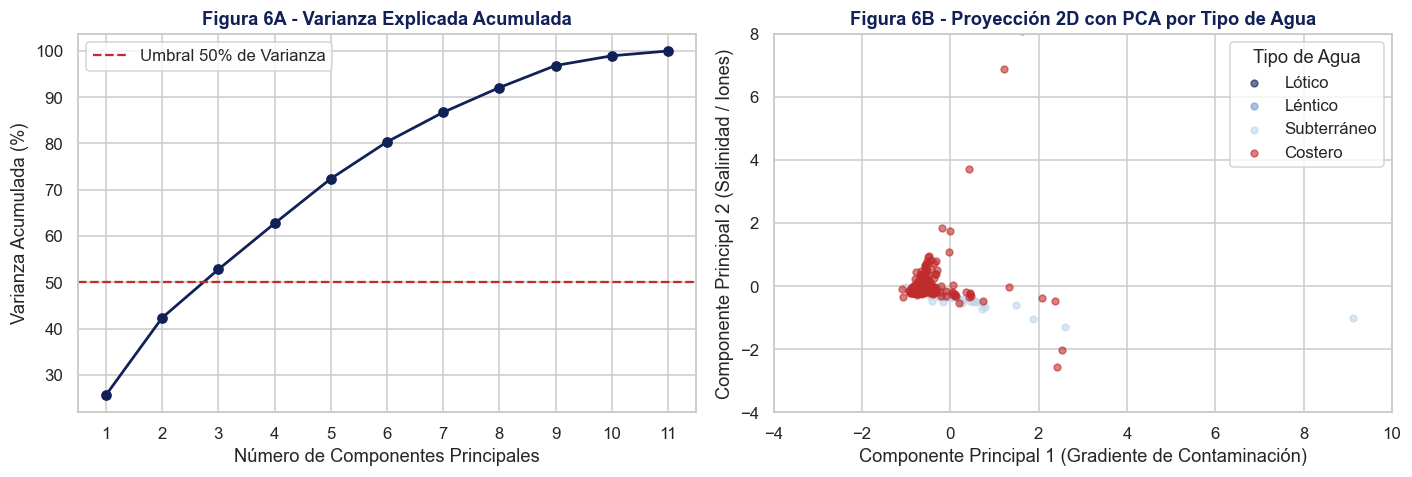

In [15]:
# Figura con dos graficos de PCA
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafico 6A: Scree Plot de Varianza Acumulada
axs[0].plot(range(1, len(var_acumulada) + 1), var_acumulada, marker="o", color=AZUL_OSCURO, linewidth=1.8)
axs[0].axhline(y=50, color=ROJO, linestyle="--", label="Umbral 50% de Varianza")
axs[0].set_title("Figura 6A - Varianza Explicada Acumulada")
axs[0].set_xlabel("Número de Componentes Principales")
axs[0].set_ylabel("Varianza Acumulada (%)")
axs[0].set_xticks(range(1, 12))
axs[0].legend()

# Grafico 6B: Proyeccion 2D por Tipo de Cuerpo de Agua
colores_agua = {"Lótico": AZUL_OSCURO, "Léntico": AZUL, "Subterráneo": AZUL_CLARO, "Costero": ROJO}
for tipo, col in colores_agua.items():
    subset = df_pca[df_pca["TIPO_AGUA"] == tipo]
    axs[1].scatter(subset["PC1"], subset["PC2"], color=col, alpha=0.6, s=20, label=tipo)

axs[1].set_title("Figura 6B - Proyección 2D con PCA por Tipo de Agua")
axs[1].set_xlabel("Componente Principal 1 (Gradiente de Contaminación)")
axs[1].set_ylabel("Componente Principal 2 (Salinidad / Iones)")
axs[1].set_xlim(-4, 10)
axs[1].set_ylim(-4, 8)
axs[1].legend(title="Tipo de Agua")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 6:**  

Figura 6A – Varianza capturada:
Los dos primeros componentes principales concentran más del 42.1 % de la información total contenida en las 11 variables. Esto permite representar los datos en menos dimensiones sin perder gran parte de la información original.

Figura 6B – Proyección 2D:
La proyección en dos dimensiones muestra patrones claros entre los distintos tipos de cuerpos de agua. El componente PC1 está relacionado principalmente con el grado de contaminación o carga orgánica, mientras que PC2 ayuda a diferenciar las aguas subterráneas, caracterizadas por una mayor mineralización y menor contenido de materia orgánica.

---

## 9. Técnica 5: Selección de Características (*Feature Selection*)

### Justificación Técnica (Guyon & Elisseeff, 2003):
Eliminación de variables repetidas:
SDT y CONDUC_CAMPO tienen una correlación muy alta (r = 0.99), lo que significa que contienen información muy similar. Por eso, se elimina SDT para evitar trabajar con información repetida.
Selección de las variables más importantes:
Se utiliza Información Mutua (mutual_info_classif) para medir qué tan relacionada está cada variable con la condición crítica del agua. Con este resultado se seleccionan las 5 variables que mejor ayudan a distinguir entre las clases.

In [16]:
# 1) Variables candidatas descartando la variable redundante SDT
variables_candidatas = [
    "pH_CAMPO",
    "OD_mg/L",
    "CONDUC_CAMPO",
    "DBO_TOT",
    "DQO_TOT",
    "COLI_FEC",
    "SST",
    "TURBIEDAD",
    "N_TOT",
    "P_TOT"
]

# 2) Calcular Informacion Mutua con respecto a la Condicion Critica
puntuaciones_mi = mutual_info_classif(
    df_smote_base[variables_candidatas],
    df_smote_base["Condicion_Critica"],
    random_state=42
)

# Convertir a serie de pandas y ordenar de mayor a menor
ranking_mi = pd.Series(puntuaciones_mi, index=variables_candidatas).sort_values(ascending=True)

# Seleccionar las 5 mejores caracteristicas
top_5_variables = ranking_mi.tail(5).index.tolist()

print("Ranking de Información Mutua:")
print(ranking_mi.sort_values(ascending=False).round(4))

print("\nTop 5 características seleccionadas:", top_5_variables)

Ranking de Información Mutua:
DBO_TOT        0.22
OD_mg/L        0.17
DQO_TOT        0.16
P_TOT          0.10
N_TOT          0.09
TURBIEDAD      0.05
COLI_FEC       0.05
CONDUC_CAMPO   0.04
SST            0.04
pH_CAMPO       0.01
dtype: float64

Top 5 características seleccionadas: ['N_TOT', 'P_TOT', 'DQO_TOT', 'OD_mg/L', 'DBO_TOT']


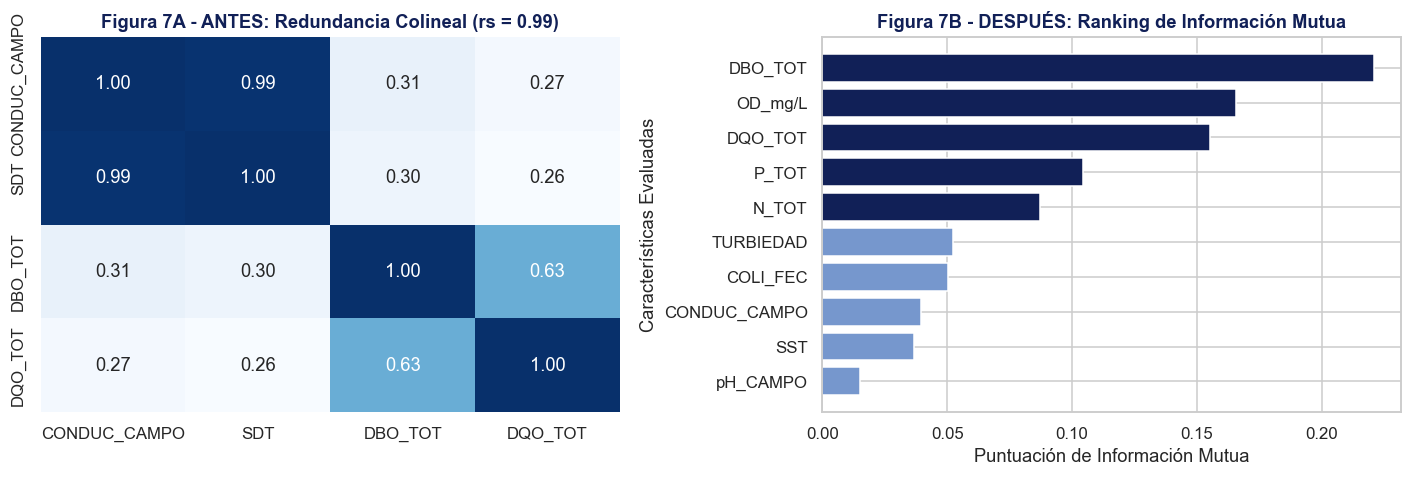

In [17]:
# Figura con dos graficos de seleccion de caracteristicas
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafico 7A: Matriz de correlacion previa resaltando la redundancia
sns.heatmap(
    df_eda[["CONDUC_CAMPO", "SDT", "DBO_TOT", "DQO_TOT"]].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=False,
    ax=axs[0]
)
axs[0].set_title("Figura 7A - ANTES: Redundancia Colineal (rs = 0.99)")

# Grafico 7B: Barras horizontales de puntuacion de Informacion Mutua
colores_barras = [AZUL if v not in top_5_variables else AZUL_OSCURO for v in ranking_mi.index]
axs[1].barh(ranking_mi.index, ranking_mi.values, color=colores_barras)
axs[1].set_title("Figura 7B - DESPUÉS: Ranking de Información Mutua")
axs[1].set_xlabel("Puntuación de Información Mutua")
axs[1].set_ylabel("Características Evaluadas")

plt.tight_layout()
plt.show()

---

### Lectura e Interpretación de la Figura 7

**Figura 7A (Antes – Redundancia):**
Se observa una correlación muy alta entre `SDT` y `CONDUC_CAMPO` (**r = 0.99**). Esto indica que ambas variables contienen información muy similar, por lo que se elimina `SDT` para evitar redundancia.

**Figura 7B (Después – Selección Final):**
La Información Mutua identifica como las 5 variables más importantes a **`DBO_TOT`**, **`OD_mg/L`**, **`DQO_TOT`**, **`P_TOT`** y **`N_TOT`**. Estas variables son las que tienen mayor relación con la condición de calidad del agua y permiten reducir el número de variables del modelo en un **55 %**.


---

## 10. Hallazgos Principales del Preprocesamiento

### Principales hallazgos

El desarrollo de las 5 técnicas de preprocesamiento aplicadas a los datos nacionales de monitoreo de agua en México permitió obtener los siguientes resultados:

1. **Limpieza de los datos:**
   Se trataron los valores censurados y los datos faltantes mediante imputación según el tipo de cuerpo de agua. Esto permitió completar el **100 % de los datos** sin modificar de forma importante su distribución (Figura 3).

2. **Uso de nuevos índices:**
   Los índices **IBO e IEUT** ayudaron a representar mejor la calidad del agua y a distinguir entre zonas con mayor deterioro y cuerpos de agua en mejores condiciones (Figura 4).

3. **Balance de clases con SMOTE:**
   La clase crítica aumentó de **273 a 2,727 observaciones sintéticas**, logrando un mejor equilibrio entre las clases y reduciendo el sesgo de los datos (Figura 5).

4. **Reducción de variables con PCA:**
   Los dos primeros componentes explicaron el **42.1 % de la variabilidad total**, permitiendo visualizar de forma más sencilla las diferencias entre los grupos de agua analizados (Figura 6).

5. **Selección de variables importantes:**
   Se eliminó la información redundante y, mediante **Información Mutua**, se seleccionaron como variables principales **DBO, OD, DQO, P y N** (Figura 7).


---

## 11. Referencias Bibliográficas (Normas APA 7.ª Edición) y herramientas utilizadas 

American Public Health Association, American Water Works Association, & Water Environment Federation. (2017). *Standard methods for the examination of water and wastewater* (23rd ed.). APHA-AWWA-WEF.

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, *16*, 321–357. https://doi.org/10.1613/jair.953

Comisión Nacional del Agua. (2025a). *Resultados de la Red Nacional de Medición de Calidad del Agua (RENAMECA)*. Secretaría de Medio Ambiente y Recursos Naturales, Gobierno de México. https://www.gob.mx/conagua

Comisión Nacional del Agua. (2025b). *Criterios ecológicos de calidad del agua: Parámetros e indicadores nacionales*. Gobierno de México.

Guyon, I., & Elisseeff, A. (2003). An introduction to variable and feature selection. *Journal of Machine Learning Research*, *3*, 1157–1182.

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences*, *374*(2065), Artículo 20150202. https://doi.org/10.1098/rsta.2015.0202

Metcalf & Eddy, Inc., Burton, F. L., Stensel, H. D., & Tsuchihashi, R. (2014). *Wastewater engineering: Treatment and resource recovery* (5th ed.). McGraw-Hill Education.

United States Environmental Protection Agency. (2000). *Guidance for data quality assessment: Practical methods for data analysis* (EPA QA/G-9, EPA/600/R-96/084). Office of Environmental Information, U.S. EPA.

Wetzel, R. G. (2001). *Limnology: Lake and river ecosystems* (3rd ed.). Academic Press.

Se utilizó ChatGPT como apoyo para realizar modificaciones sencillas en código Python, principalmente en el uso de las funciones `apply()`, `groupby()`, `transform()`, `fillna()` y `mutual_info_classif()`, relacionadas con la limpieza, imputación y selección de variables. También se utilizó para corregir la redacción y ortografía de algunos párrafos. El análisis e interpretación de los resultados fueron realizados y revisados por el autor.

